In [34]:
# Imports
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Get the notebook directory and navigate to project root
notebook_dir = Path(os.getcwd())
if notebook_dir.name == "notebooks":
    REPO_ROOT = notebook_dir.parent
else:
    REPO_ROOT = notebook_dir

sys.path.append(str(REPO_ROOT))

In [35]:
# Load data
costs = pd.read_csv(REPO_ROOT / "data/costs_2030.csv")
timeseries = pd.read_csv(REPO_ROOT / "data/time_series_2030.csv", index_col=0, parse_dates=True)

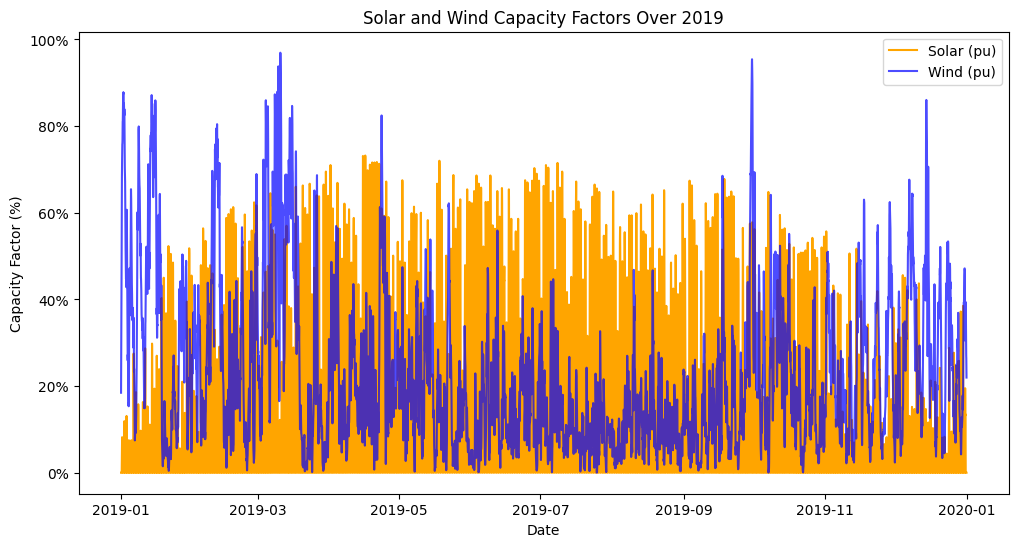

In [36]:
# Plot timeseries data with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot pv_pu and wind_pu on left axis
ax1.plot(timeseries.index, timeseries["pv_pu"], label="Solar (pu)", color="orange")
ax1.plot(timeseries.index, timeseries["wind_pu"], label="Wind (pu)", color="blue", alpha=0.7)
ax1.set_xlabel("Date")
ax1.set_ylabel("Capacity Factor (%)", color="black")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.tick_params(axis="y")
ax1.legend()

plt.title("Solar and Wind Capacity Factors Over 2019")
plt.show()

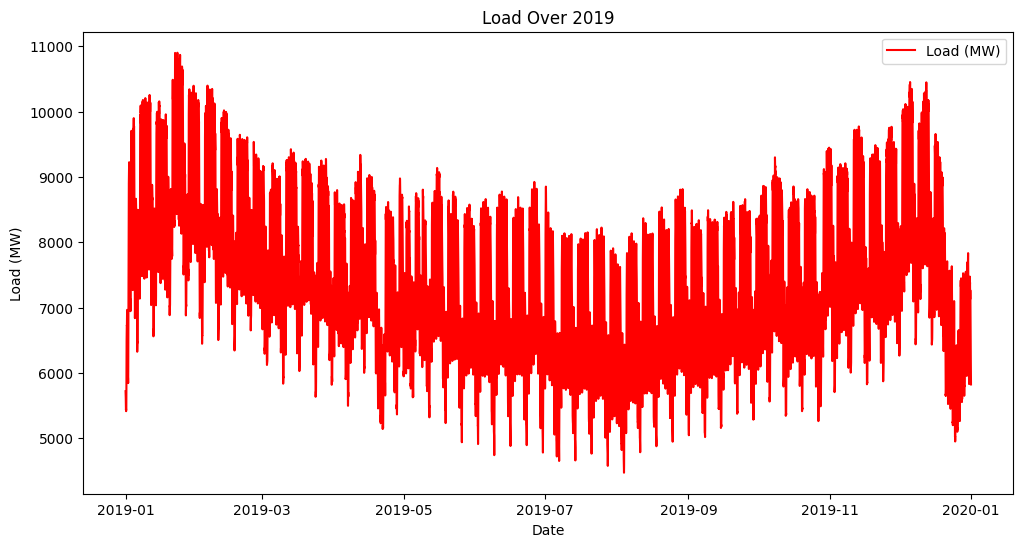

In [37]:
# Plot timeseries data with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot pv_pu and wind_pu on left axis
ax1.plot(timeseries.index, timeseries["load_mw"], label="Load (MW)", color="red")
ax1.set_xlabel("Date")
ax1.set_ylabel("Load (MW)", color="black")
ax1.tick_params(axis="y")
ax1.legend()

plt.title("Load Over 2019")
plt.show()

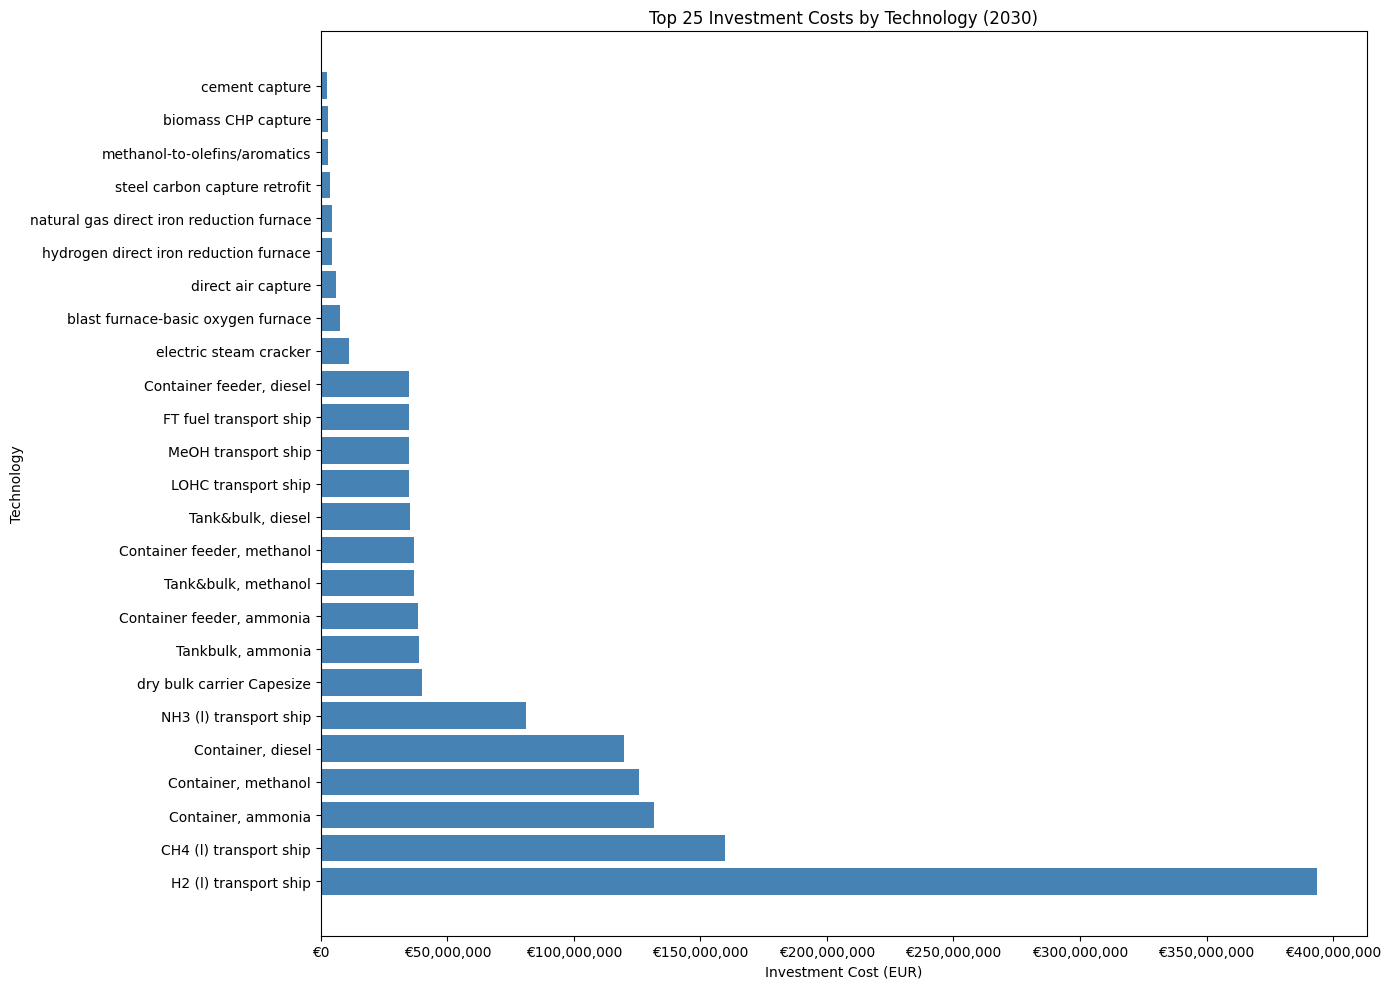

In [38]:
n_top_investment = 25

# Bar chart of investment costs by technology
investment_df = costs[costs["parameter"] == "investment"].copy()
top_n_investment_df = investment_df.sort_values("value", ascending=False).head(n_top_investment)

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(top_n_investment_df["technology"], top_n_investment_df["value"], color="steelblue")
ax.set_xlabel("Investment Cost (EUR)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{x:,.0f}"))
ax.set_ylabel("Technology")
ax.set_title(f"Top {n_top_investment} Investment Costs by Technology (2030)")
plt.tight_layout()
plt.show()

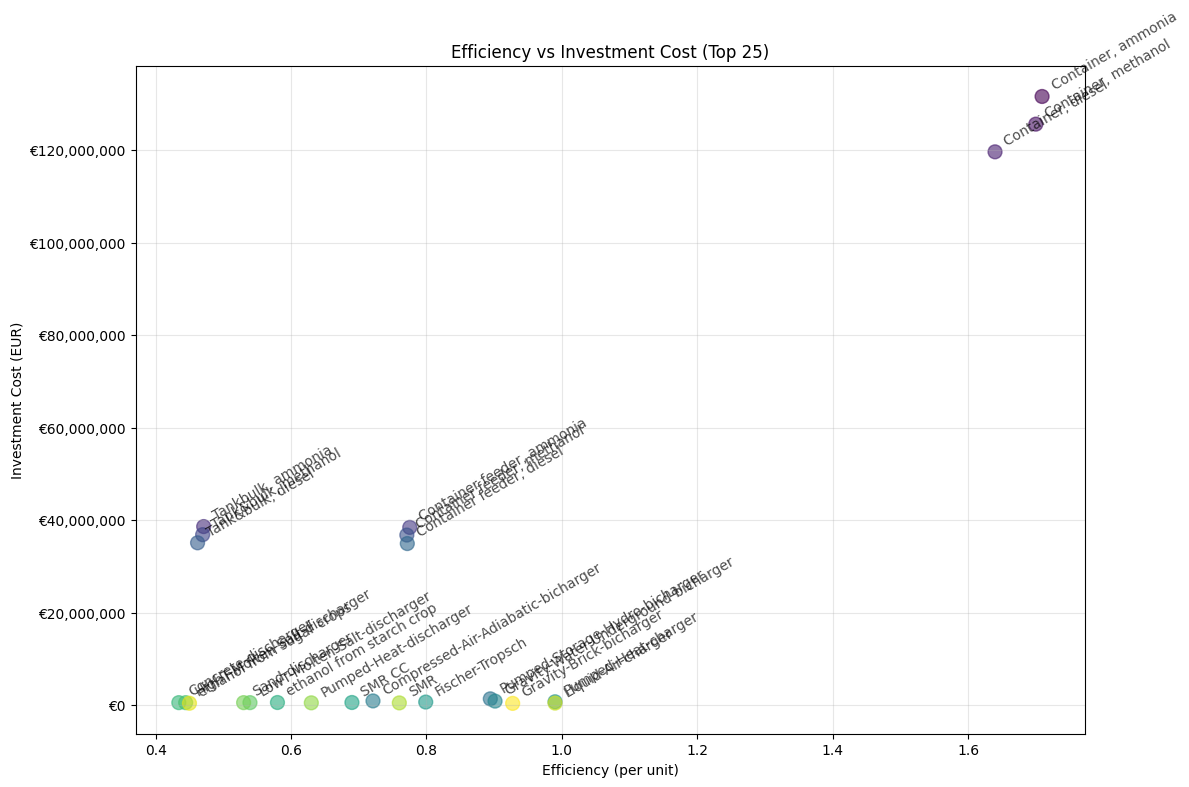

In [39]:
# Scatter plot of efficiency vs investment cost
# Get efficiency and investment data
efficiency_df = costs[costs["parameter"] == "efficiency"][["technology", "value"]].rename(
    columns={"value": "efficiency"}
)
investment_df = costs[costs["parameter"] == "investment"][["technology", "value"]].rename(
    columns={"value": "investment"}
)

# Merge the two datasets
merged_data = pd.merge(efficiency_df, investment_df, on="technology", how="inner")

# Get top n_top_investment by investment cost
top_n_merged = merged_data.nlargest(n_top_investment, "investment")

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    top_n_merged["efficiency"],
    top_n_merged["investment"],
    s=100,
    alpha=0.6,
    c=range(len(top_n_merged)),
    cmap="viridis",
)
ax.set_xlabel("Efficiency (per unit)")
ax.set_ylabel("Investment Cost (EUR)")

# Format y-axis as euros
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"€{y:,.0f}"))

ax.set_title(f"Efficiency vs Investment Cost (Top {n_top_investment})")
ax.grid(True, alpha=0.3)

# Add labels for some key points
for idx, row in top_n_merged.iterrows():
    if row["investment"] > 200000 or row["efficiency"] > 0.8:
        ax.annotate(
            row["technology"],
            (row["efficiency"], row["investment"]),
            fontsize=10,
            alpha=0.7,
            xytext=(5, 5),
            textcoords="offset points",
            rotation=30,
        )

plt.tight_layout()
plt.show()

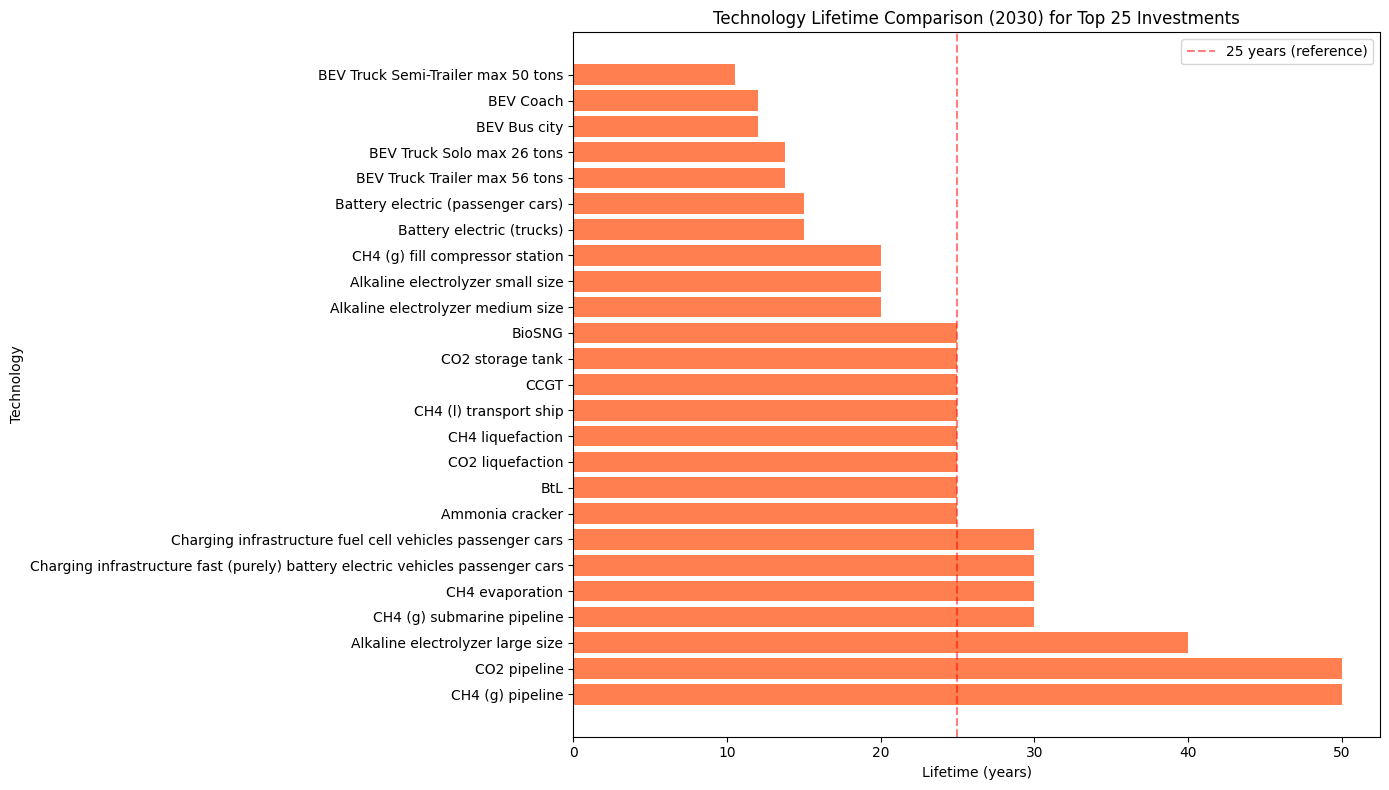

In [40]:
# Lifetime comparison across technologies
top_n_lifetime_df = costs[costs["parameter"] == "lifetime"].copy().head(n_top_investment)
top_n_lifetime_df = top_n_lifetime_df.sort_values("value", ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top_n_lifetime_df["technology"], top_n_lifetime_df["value"], color="coral")
ax.set_xlabel("Lifetime (years)")
ax.set_ylabel("Technology")
ax.set_title(f"Technology Lifetime Comparison (2030) for Top {n_top_investment} Investments")
ax.axvline(
    x=n_top_investment,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="25 years (reference)",
)
ax.legend()
plt.tight_layout()
plt.show()

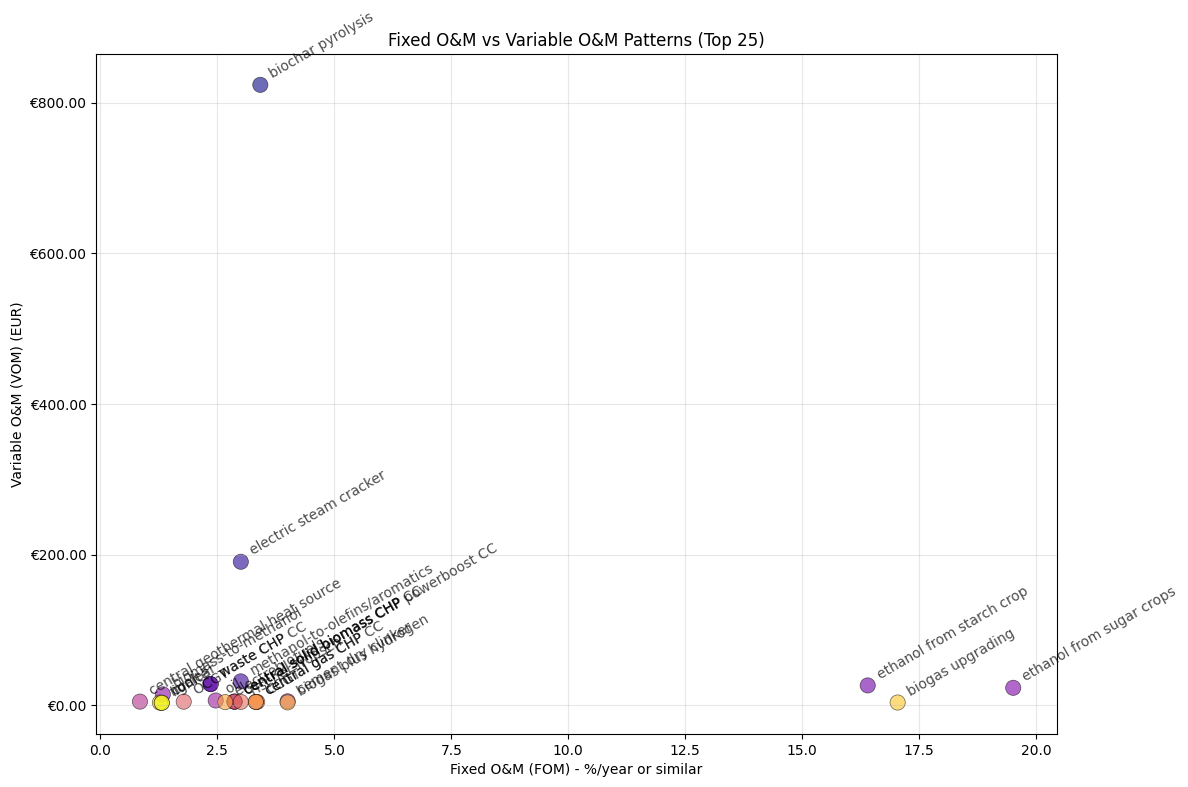

In [41]:
# FOM (Fixed O&M) vs VOM (Variable O&M) patterns
fom_df = costs[costs["parameter"] == "FOM"][["technology", "value"]].rename(
    columns={"value": "FOM"}
)
vom_df = costs[costs["parameter"] == "VOM"][["technology", "value"]].rename(
    columns={"value": "VOM"}
)

# Merge the two datasets
om_data = pd.merge(fom_df, vom_df, on="technology", how="inner")

# Get top n_top_investment by VOM
top_n_om = om_data.nlargest(n_top_investment, "VOM")

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    top_n_om["FOM"],
    top_n_om["VOM"],
    s=120,
    alpha=0.6,
    c=range(len(top_n_om)),
    cmap="plasma",
    edgecolors="black",
    linewidth=0.5,
)
ax.set_xlabel("Fixed O&M (FOM) - %/year or similar")
ax.set_ylabel("Variable O&M (VOM) (EUR)")

# Format y-axis as euros
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"€{y:,.2f}"))

ax.set_title(f"Fixed O&M vs Variable O&M Patterns (Top {n_top_investment})")
ax.grid(True, alpha=0.3)

# Add labels for all points
for idx, row in top_n_om.iterrows():
    ax.annotate(
        row["technology"],
        (row["FOM"], row["VOM"]),
        fontsize=10,
        alpha=0.7,
        xytext=(5, 5),
        textcoords="offset points",
        rotation=30,
    )

plt.tight_layout()
plt.show()